SENSITIVITY ANALYSIS
---------------------

This would help to understand the behaviour of each of the features of each function

Result of this will be 1D chart for each of the dimension and how it behaves against the output

Redline you see is where the current best point is. 

This would help to understand the impact of the dimension/feature to the output

* Flat means it has no or minimal impact

* Steeper the curve is tells you how output is related

-------------------------------------------------------

Analyzing Function 1 (2 Dimensions)...


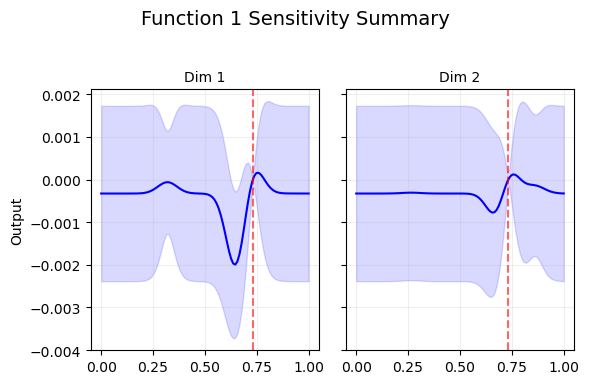

Analyzing Function 2 (2 Dimensions)...


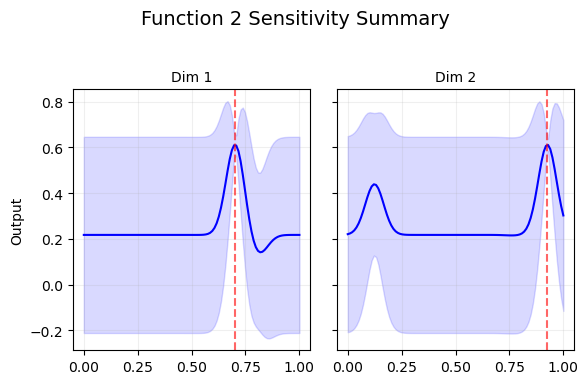

Analyzing Function 3 (3 Dimensions)...


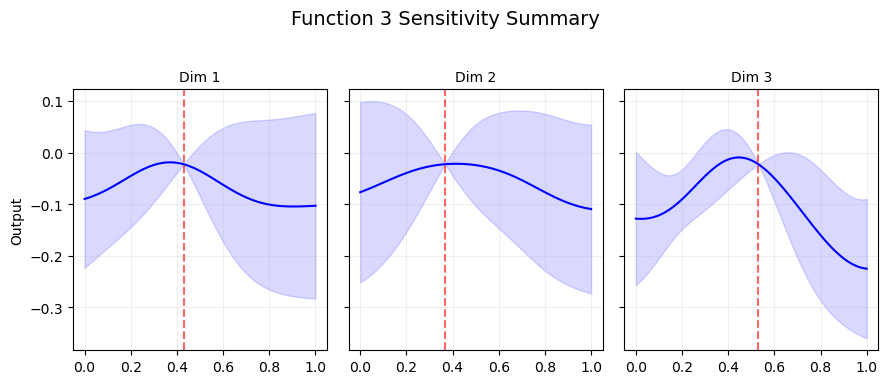

Analyzing Function 4 (4 Dimensions)...


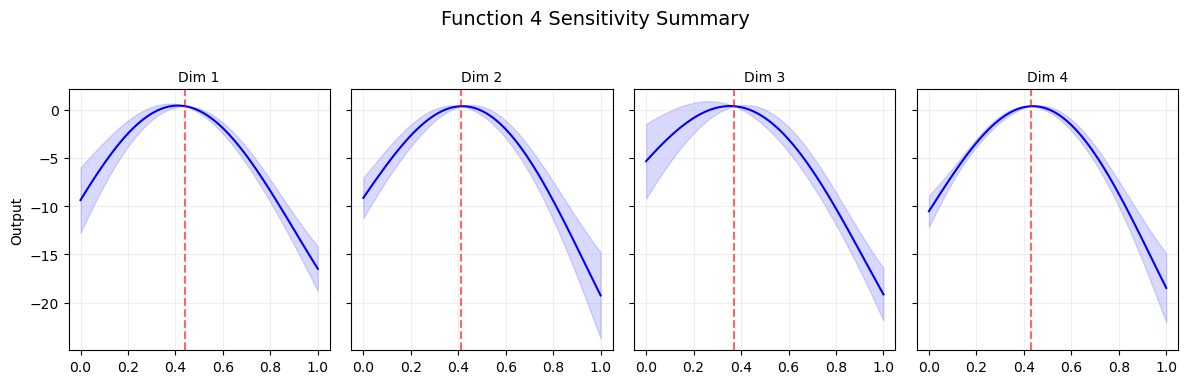

Analyzing Function 5 (4 Dimensions)...


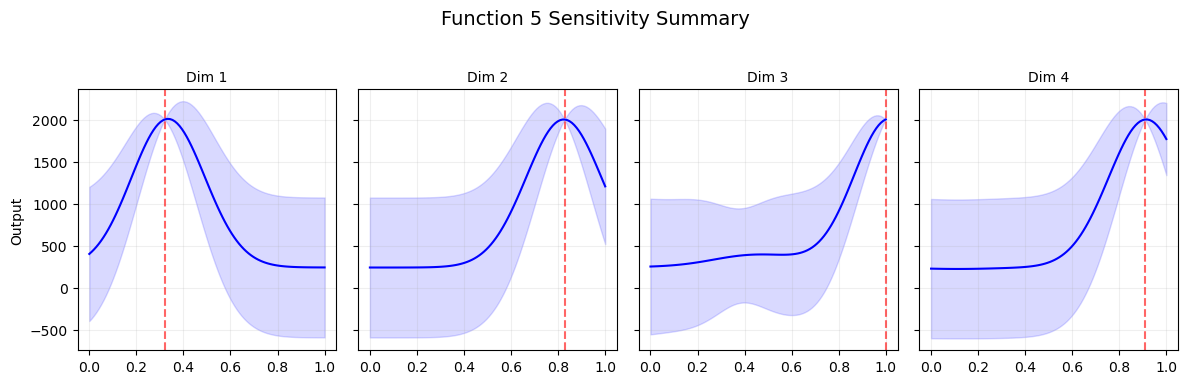

Analyzing Function 6 (5 Dimensions)...


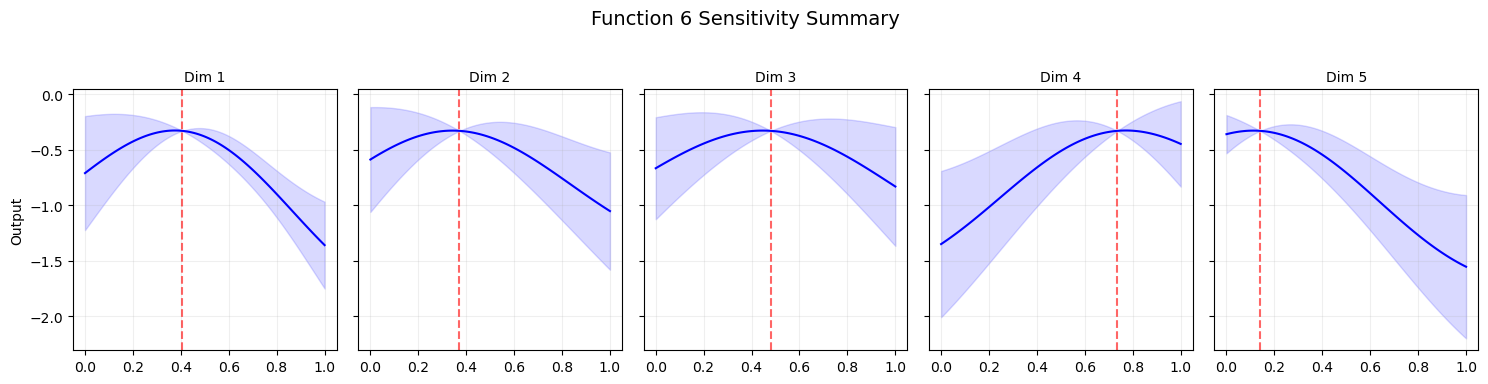

Analyzing Function 7 (6 Dimensions)...


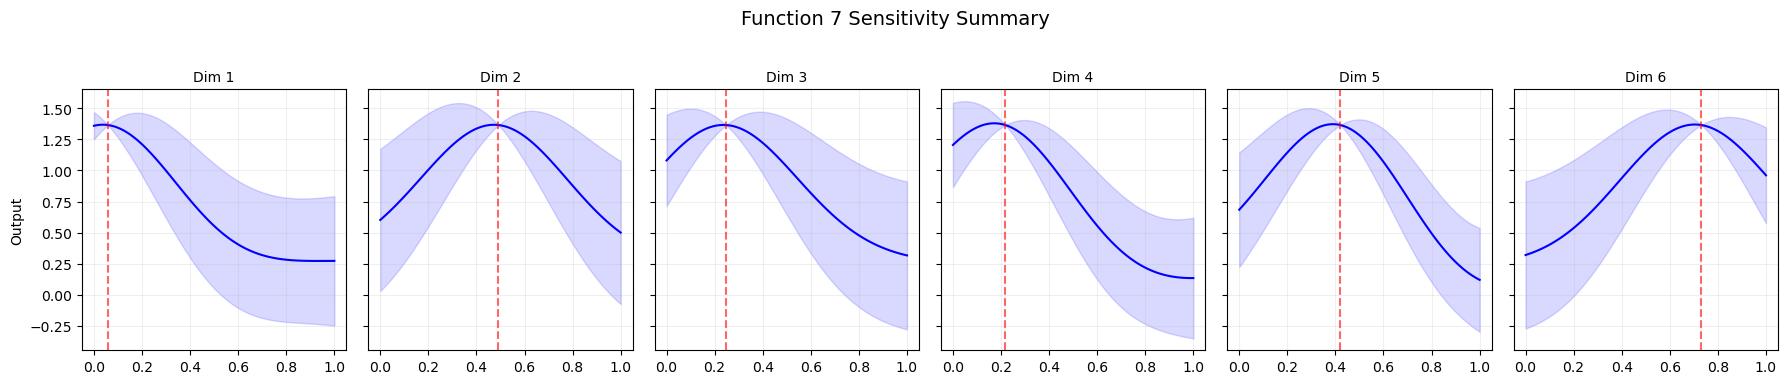

Analyzing Function 8 (8 Dimensions)...


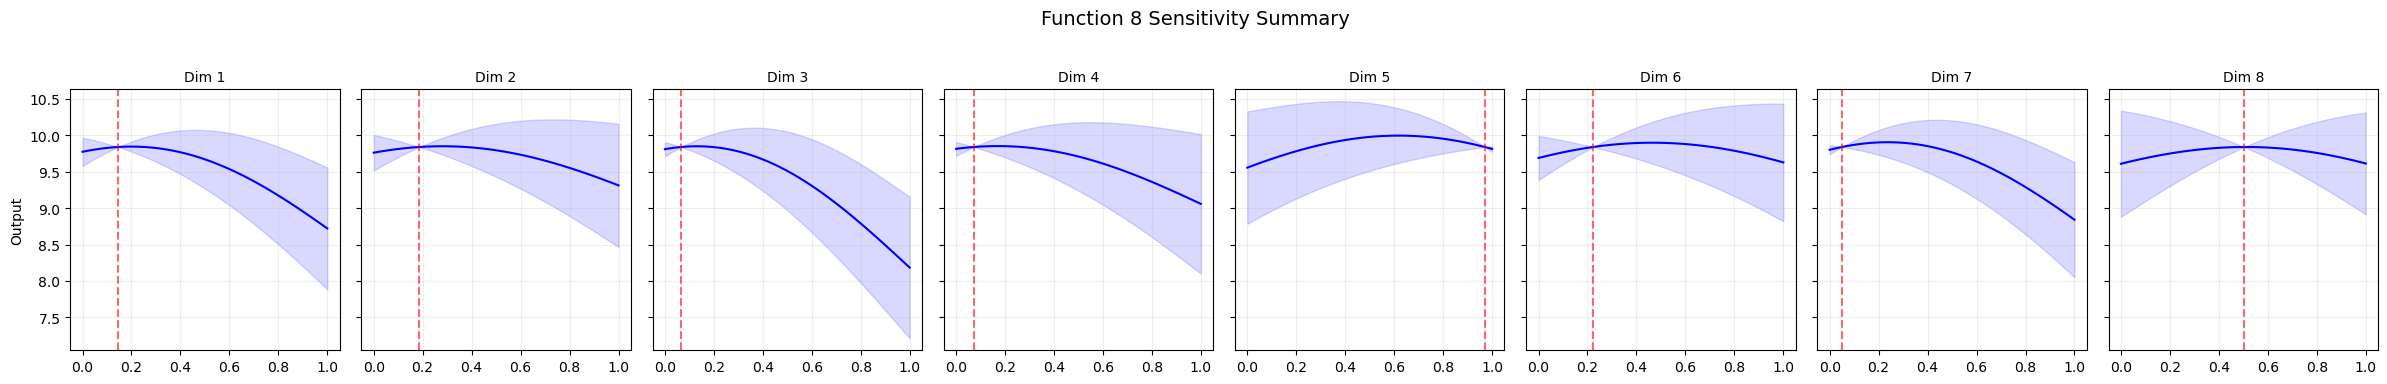

In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# 1. Loop through all 8 functions
for fn_num in range(1, 9):
    path = f'capstone_data/initial_data/function_{fn_num}/'
    
    # Load Data
    try:
        X = np.load(os.path.join(path, 'initial_inputs.npy'))
        y = np.load(os.path.join(path, 'initial_outputs.npy'))
    except FileNotFoundError:
        print(f"Skipping Function {fn_num}: Data files not found.")
        continue

    # 2. Fit Gaussian Process
    kernel = C(1.0, (1e-3, 1e3)) * RBF(0.1, (1e-2, 1e2))
    gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)
    gp.fit(X, y)

    # 3. Identify the "Best Point" Anchor
    best_x = X[np.argmax(y)]
    num_dims = X.shape[1]

    # 4. Create Plotting Grid
    fig, axes = plt.subplots(1, num_dims, figsize=(3 * num_dims, 4), sharey=True)
    if num_dims == 1: axes = [axes]

    print(f"Analysing Function {fn_num} ({num_dims} Dimensions)...")

    for dim in range(num_dims):
        ax = axes[dim]
        sweep_values = np.linspace(0, 1, 100)
        
        test_points = np.tile(best_x, (100, 1))
        test_points[:, dim] = sweep_values
        
        mu, sigma = gp.predict(test_points, return_std=True)
        
        ax.plot(sweep_values, mu, color='blue', lw=1.5)
        ax.fill_between(sweep_values, mu - 1.96*sigma, mu + 1.96*sigma, alpha=0.15, color='blue')
        ax.axvline(best_x[dim], color='red', linestyle='--', alpha=0.6)
        
        ax.set_title(f'Dim {dim+1}', fontsize=10)
        if dim == 0: ax.set_ylabel('Output')
        ax.grid(True, alpha=0.2)

    plt.suptitle(f'Function {fn_num} Sensitivity Summary', fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show() # Or plt.savefig(f'sensitivity_fn_{fn_num}.png')